[*********************100%***********************]  1 of 1 completed


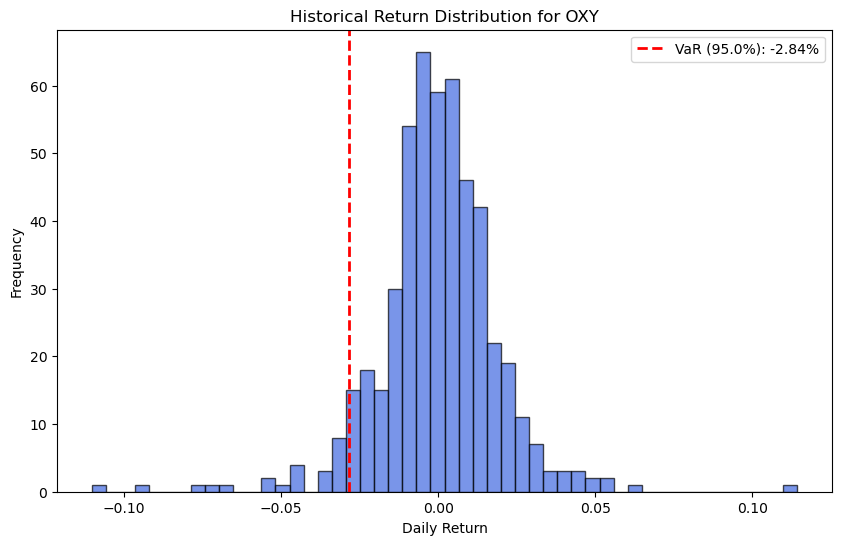

OXY 1-Day 95% VaR: -2.84%


In [2]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def calculate_var(ticker, confidence_level=0.95):
    # 1. Download historical data
    data = yf.download(ticker, period="2y")['Close']
    
    # Handle potential MultiIndex
    if isinstance(data, pd.DataFrame):
        data = data[ticker]
    
    # 2. Calculate daily returns
    returns = data.pct_change().dropna()
    
    # 3. Calculate Historical VaR
    # For 95% confidence, we look at the bottom 5th percentile
    var_percentile = (1 - confidence_level) * 100
    var_value = np.percentile(returns, var_percentile)
    
    # 4. Visualization
    plt.figure(figsize=(10, 6))
    plt.hist(returns, bins=50, alpha=0.7, color='royalblue', edgecolor='black')
    
    # Draw the VaR line
    plt.axvline(var_value, color='red', linestyle='--', linewidth=2, 
                label=f'VaR ({confidence_level*100}%): {var_value:.2%}')
    
    plt.title(f"Historical Return Distribution for {ticker}")
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()
    
    return var_value

# Let's test it on a volatile energy stock
oxy_var = calculate_var("OXY")
print(f"OXY 1-Day 95% VaR: {oxy_var:.2%}")